In [73]:
import numpy as np
import matplotlib.pyplot as plt
import arya

from astropy.table import Table

import pyneb as pn

In [12]:
dwarf_cat = Table.read("stellar_mass_emline_dwarfs.fits").to_pandas()

In [80]:
lines = ["oiii4363", "oii3726", "oii3729", "oiii5007", "halpha", "hbeta"]

In [70]:
filt = np.full(len(dwarf_cat), False)

# at least 1 auroal line
for line in ["oiii4363"]:
    snr = dwarf_cat[line + "_flux"] / dwarf_cat[line + "_fluxerr"]
    filt |= snr > 5

print(np.sum(filt))

for line in ["oii3726", "oii3729", "oiii5007", "hbeta"]:
    snr = dwarf_cat[line + "_flux"] / dwarf_cat[line + "_fluxerr"]
    filt &= snr > 3




print(np.sum(filt))

# quality cuts from Schotle+2026
filt &= dwarf_cat["deltachi2"] >= 40
filt &= dwarf_cat["zcat_primary"] == b't'
filt &= dwarf_cat["spectype"] == b"GALAXY"
filt &= dwarf_cat["zwarn"] == 0

filt &= dwarf_cat["hbeta_ew"] > 20

filt &= dwarf_cat["oiii4363_sigma"] < 2
filt &= (dwarf_cat["halpha_flux"] / dwarf_cat["halpha_fluxerr"] > 3) # or hbeta


print(np.sum(filt))

1188
1165
928


In [71]:
good_cat = dwarf_cat[filt].drop_duplicates()

In [72]:
good_cat

,xj_sl,target_ra,target_dec,z,zerr,plate_ra,plate_dec,mgii2796_center,mgii2796_centererr,mgii2796_flux,...,sga_norm_d26_dist,aperture_photometry_done,logm_saga_aper,mag_g_aper,mag_r_aper,mag_z_aper,nearest_star_dist,mag_g_updated,mag_r_updated,mag_z_updated
407,"b'{0,0,0,0,0,0,0,0,0,0,0,12.65040016174316,37....",321.435047,11.627708,0.029955,4.100276e-07,321.435047,11.627708,0.0,0.0,0.0,...,77.967401,0,-99.0,-99.0,-99.0,-99.0,-99.0,17.918453,17.918076,18.040905
2225,"b'{32.03300094604492,0,0,0,0,0,0,0,0,0,0,13.33...",329.088393,17.410190,0.033934,5.231893e-07,329.088393,17.410190,0.0,0.0,0.0,...,41.813770,0,-99.0,-99.0,-99.0,-99.0,-99.0,16.703703,16.713722,16.794779
3196,"b'{43.51050186157227,0,0,0,0,0,0,0,0,0,0.00300...",326.881138,21.566368,0.032296,5.622737e-07,326.881138,21.566368,0.0,0.0,0.0,...,682.735590,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.372139,19.468773,19.734047
3366,"b'{51.20510101318359,0,0,0,0,0,0,0,0,0,0,0,7.3...",333.247108,22.084862,0.028710,3.779562e-07,333.247108,22.084862,0.0,0.0,0.0,...,336.938492,0,-99.0,-99.0,-99.0,-99.0,-99.0,17.361536,17.832712,18.364796
3502,"b'{34.43610000610352,0,0,0,0,0,0,0,0,4.5606999...",326.798876,22.831782,0.022326,4.956544e-07,326.798876,22.831782,0.0,0.0,0.0,...,157.320675,0,-99.0,-99.0,-99.0,-99.0,-99.0,17.969568,17.972752,18.160484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660444,"b'{0,1.06850004196167,5.06279993057251,0,0,0,0...",185.987225,67.450337,0.031826,8.718602e-07,185.987225,67.450337,0.0,0.0,0.0,...,83.949674,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.251192,19.197556,19.302456
661888,"b'{28.37660026550293,0,0,0,0,0.003400000045076...",191.847863,77.038217,0.088067,4.849368e-07,191.847863,77.038217,0.0,0.0,0.0,...,795.400009,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.042665,19.364235,19.392895
662077,"b'{37.66279983520508,0,0,0,0,0,0,0,0,0,0,2.952...",316.108979,1.213630,0.023554,3.443492e-07,316.108979,1.213630,0.0,0.0,0.0,...,369.310855,0,-99.0,-99.0,-99.0,-99.0,-99.0,16.907745,17.213257,17.587690
662240,"b'{35.32600021362305,0,6.903900146484375,0.000...",314.733327,2.379591,0.028788,7.168235e-07,314.733327,2.379591,0.0,0.0,0.0,...,20.483726,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.256960,19.360783,19.522835


In [396]:
print(good_cat["targetid"].to_list())

[39628072189695697, 39628206772327180, 39628297910357727, 39628309243366322, 39628325907335510, 39628370228549309, 39628364897588483, 39628403002841832, 39628408598037585, 39628424762888224, 39628472473096966, 39628529658234298, 39633059447838286, 39633196811291388, 39633200925904049, 39633217371769585, 39633221322804356, 39633225366111632, 39633237294715130, 39633237319881605, 39633237391185109, 39633275878117320, 39633279619432590, 39633283285259410, 39633414218843994, 39633446477235211, 39633451392960261, 39633470615453779, 39633470649010643, 39633496385259595, 39627490846573810, 39627520357700745, 39627633884922128, 39627682060699059, 39627634438579712, 39627688494764473, 39627706547045668, 39627730743986891, 39627718853136594, 39627730836265441, 39627749035351977, 39627755238725057, 39627773160983851, 39627797492146845, 39627815485706870, 39627827485612702, 39627827661769567, 39627839636508135, 39627845642753157, 39627857739124014, 39627863690843678, 39627887887785706, 39627700377

In [394]:
good_cat["targetid"].values[np.argsort(good_cat["halpha_flux"] / good_cat["halpha_fluxerr"])][-10:-1]

array([39633232039250152, 39633285550180246, 39627865951568761,
       39627630667894593, 39628472473096966, 39636465713416354,
       39628082889364913, 39633158471159660, 39633275769064365])

# Emission line fitting

In [101]:
line_labels = {
    "oiii4363": "O3_4363A",
    "oii3726": "O2_3726A",
    "oii3729": "O2_3729A",
    "oiii5007": "O3_5007A",
    "hbeta": "H1r_4861A",
    "halpha": "H1r_6563A"
}

In [128]:
def write_observation(catalogue, filename):
    with open(filename, "w") as f:

        f.write("NAME\t")
        for line in lines:
            f.write(line_labels[line] + "\t")
            f.write(line_labels[line] + "_e" + "\t")
        f.write("\n")

        
        for idx, row in catalogue.iterrows():
            f.write(str(row["targetid"]) + "\t")
            for line in lines:
                f.write(str(row[line + "_flux"]))
                f.write("\t")
                f.write(str(row[line + "_fluxerr"]))
                f.write("\t")

            f.write("\n")


In [134]:
write_observation(good_cat, "good_emlines.tsv")

In [384]:
obs = pn.Observation("good_emlines.txt")

In [385]:
obs.def_EBV()
E_BV = obs.extinction.E_BV

E_BV[E_BV < 0] = 0

obs.extinction.E_BV = E_BV
obs.correctData()

In [386]:
print(obs.getIntens(obsName=obs.names[1]))
print()

print(obs.getIntens(obsName=obs.names[1], returnObs=True))

{'O3_4363A': np.float64(118.13423799301539), 'O2_3726A': np.float64(1169.4002892492044), 'O2_3729A': np.float64(1621.5209830865494), 'O3_5007A': np.float64(8892.85044986161), 'H1r_6563A': np.float64(4391.450840742694), 'H1r_4861A': np.float64(1540.8599441202434)}

{'O3_4363A': np.float64(91.28791809082031), 'O2_3726A': np.float64(871.4585571289062), 'O2_3729A': np.float64(1208.6090087890625), 'O3_5007A': np.float64(7146.43505859375), 'H1r_6563A': np.float64(3785.426513671875), 'H1r_4861A': np.float64(1226.9779052734375)}


### Electron temperature

In [148]:
diags = pn.Diagnostics()

diags.addDiagsFromObs(obs)

In [167]:
diags.diags

{'[OII] 3726/3729': ('O2', 'L(3726)/L(3729)', 'RMS([E(3729), E(3726)])'),
 '[OIII] 4363/5007': ('O3', 'L(4363)/L(5007)', 'RMS([E(5007), E(4363)])')}

In [190]:
# this simply evaluates the flux ratio between these lines

r_oii = diags.eval_diag("[OII] 3726/3729", obs)
r_oiii = diags.eval_diag("[OIII] 4363/5007", obs)

In [188]:
intens =  obs.getIntens()

In [164]:
Nobs = len(intens["O3_4363A"])

In [176]:
Te, Ne = diags.getCrossTemDen("[OIII] 4363/5007", "[OII] 3726/3729", r_oiii, r_oii)

(array([190.,  37.,  38.,  41.,  52.,  52.,  37.,  51.,  52.,  50.,  39.,
         42.,  34.,  31.,  35.,  33.,  24.,  23.,   6.,  16.,   7.,   7.,
          6.,   4.,   6.,   6.,   1.,   0.,   1.,   3.,   1.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   1.]),
 array([0.        , 0.00752125, 0.01504251, 0.02256376, 0.03008501,
        0.03760626, 0.04512752, 0.05264877, 0.06017002, 0.06769128,
        0.07521253, 0.08273378, 0.09025503, 0.09777629, 0.10529754,
        0.11281879, 0.12034004, 0.1278613 , 0.13538255, 0.1429038 ,
        0.15042506, 0.15794631, 0.16546756, 0.17298881, 0.18051007,
        0.18803132, 0.19555257, 0.20307383, 0.21059508, 0.21811633,
        0.22563758, 0.23315884, 0.24068009, 0.24820134, 0.2557226 ,
        0.26324385, 0.2707651 , 0.27828635, 0.28580761, 0.29332886,
        0.30085011, 0.30837136, 0.31589262, 0.32341387, 0.33093512,
        0.33845638, 0.34597763, 0.35349888, 0.

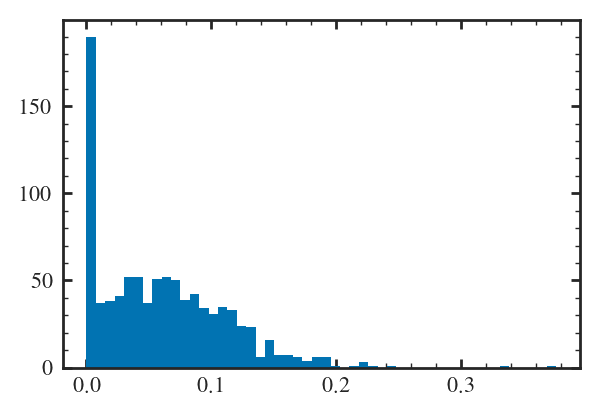

In [191]:
plt.hist(obs.extinction.E_BV)

(array([ 1.,  4.,  0.,  7.,  8., 12., 23., 25., 17., 37., 37., 36., 46.,
        44., 44., 40., 49., 48., 52., 34., 37., 28., 29., 27., 31., 17.,
        24., 17., 14., 12., 13., 11.,  3.,  5.,  3.,  3.,  1.,  0.,  3.,
         2.,  0.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  1.]),
 array([ 9349.85368075,  9640.15553787,  9930.457395  , 10220.75925212,
        10511.06110925, 10801.36296638, 11091.6648235 , 11381.96668063,
        11672.26853775, 11962.57039488, 12252.872252  , 12543.17410913,
        12833.47596626, 13123.77782338, 13414.07968051, 13704.38153763,
        13994.68339476, 14284.98525188, 14575.28710901, 14865.58896613,
        15155.89082326, 15446.19268039, 15736.49453751, 16026.79639464,
        16317.09825176, 16607.40010889, 16897.70196601, 17188.00382314,
        17478.30568026, 17768.60753739, 18058.90939452, 18349.21125164,
        18639.51310877, 18929.81496589, 19220.11682302, 19510.41868014,
        19800.72053727, 20091.02239439, 20381.32425152, 20671.626108

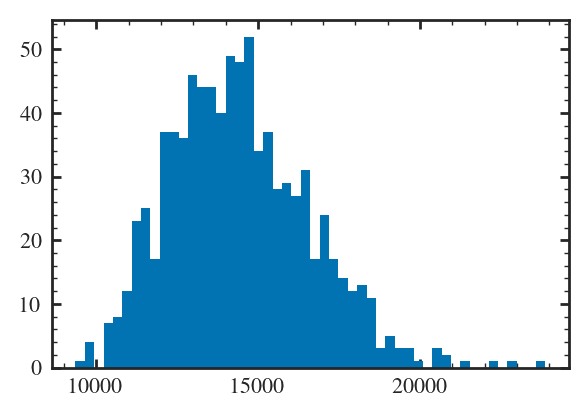

In [192]:
plt.hist(Te)

(array([  3.,   0.,   0.,   0.,   5.,   0.,   0.,   0.,   3.,   0.,   3.,
          0.,   1.,   2.,   4.,   1.,   0.,   5.,   4.,   3.,   8.,   7.,
          7.,  12.,  13.,  17.,  17.,  29.,  44.,  52.,  38.,  66.,  57.,
         87., 104.,  69.,  65.,  40.,  30.,  17.,  11.,   8.,   4.,   1.,
          3.,   0.,   1.,   2.,   0.,   3.]),
 array([0.        , 0.06736808, 0.13473615, 0.20210423, 0.2694723 ,
        0.33684038, 0.40420845, 0.47157653, 0.53894461, 0.60631268,
        0.67368076, 0.74104883, 0.80841691, 0.87578499, 0.94315306,
        1.01052114, 1.07788921, 1.14525729, 1.21262536, 1.27999344,
        1.34736152, 1.41472959, 1.48209767, 1.54946574, 1.61683382,
        1.68420189, 1.75156997, 1.81893805, 1.88630612, 1.9536742 ,
        2.02104227, 2.08841035, 2.15577842, 2.2231465 , 2.29051458,
        2.35788265, 2.42525073, 2.4926188 , 2.55998688, 2.62735496,
        2.69472303, 2.76209111, 2.82945918, 2.89682726, 2.96419533,
        3.03156341, 3.09893149, 3.16629956, 3.

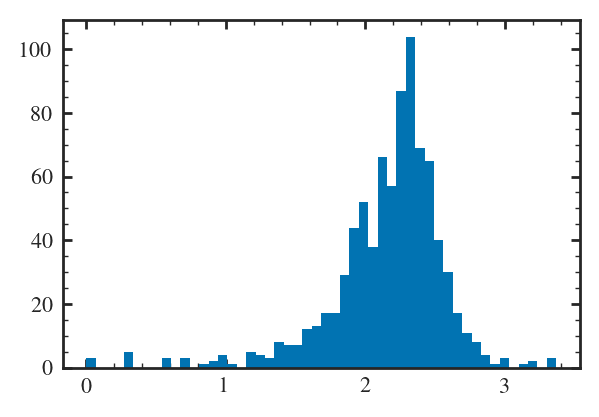

In [194]:
plt.hist(np.log10(Ne))

In [218]:
all_atoms = pn.getAtomDict(atom_list=obs.getUniqueAtoms())

warng _ManageAtomicData: atom data not available for H1
warng _ManageAtomicData: coll data not available for H1


In [225]:
ion_abund = {}


for line in obs.getSortedLines():
    if line.atom == 'H1r':
        continue

    print(line)

    ion_abund[line] = all_atoms[line.atom].getIonAbundance(line.corrIntens, Te, Ne, 
        to_eval = line.to_eval, Hbeta=intens["H1r_4861A"])
    

Line O2 O2_3726A
Line O2 O2_3729A
Line O3 O3_4363A
Line O3 O3_5007A


In [226]:
all_atoms[obs_lines[1].atom].getIonAbundance

<bound method RecAtom.getIonAbundance of Atom H1 from h_i_rec_SH95.hdf5>

In [239]:
for line in  ion_abund:
    mean = np.nanmean(np.asarray(ion_abund[line]))
    print('{:16s}: {:4.6f}'.format(str(line), 12+np.log10(mean)))

Line O2 O2_3726A: 7.291028
Line O2 O2_3729A: 7.291043
Line O3 O3_4363A: 7.850184
Line O3 O3_5007A: 7.850192


In [228]:
obs_lines = obs.getSortedLines()

In [229]:
obs_lines

[Line H1r H1r_4861A,
 Line H1r H1r_6563A,
 Line O2 O2_3726A,
 Line O2 O2_3729A,
 Line O3 O3_4363A,
 Line O3 O3_5007A]

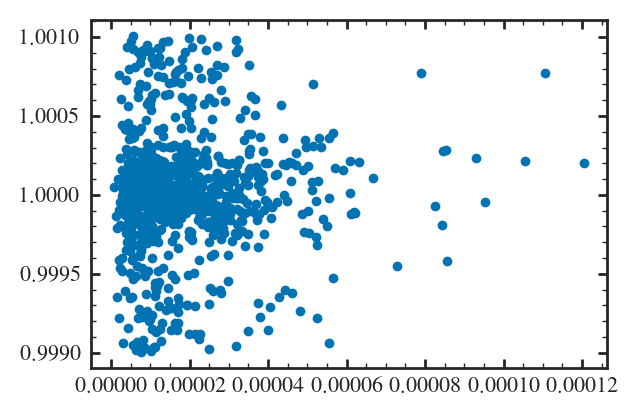

In [230]:
plt.scatter(ion_abund[obs_lines[2]], ion_abund[obs_lines[3]] / ion_abund[obs_lines[2]])

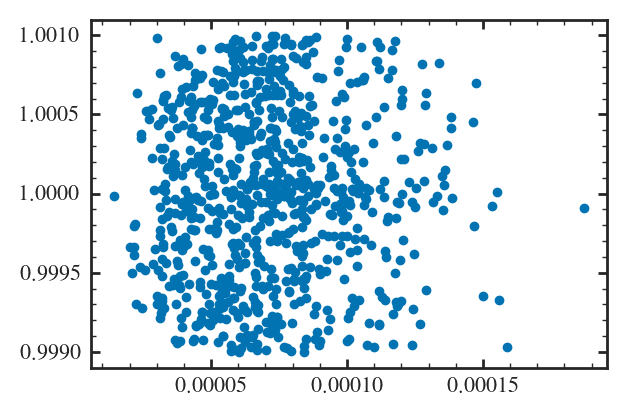

In [231]:
plt.scatter(ion_abund[obs_lines[4]], ion_abund[obs_lines[5]] / ion_abund[obs_lines[4]])

In [240]:
OII_H = (ion_abund[obs_lines[2]] + ion_abund[obs_lines[3]]) / 2
OIII_H = (ion_abund[obs_lines[4]] + ion_abund[obs_lines[5]]) / 2


In [244]:
O_H = OII_H + OIII_H

In [245]:
eps_o = np.log10(O_H) + 12

(array([  1.,   0.,   3.,   7.,   5.,  25.,  40.,  47.,  72.,  75.,  98.,
        129., 119.,  78.,  66.,  43.,  26.,   7.,   4.,   1.]),
 array([7.18915302, 7.25409352, 7.31903403, 7.38397453, 7.44891504,
        7.51385554, 7.57879605, 7.64373655, 7.70867706, 7.77361756,
        7.83855806, 7.90349857, 7.96843907, 8.03337958, 8.09832008,
        8.16326059, 8.22820109, 8.2931416 , 8.3580821 , 8.42302261,
        8.48796311]),
 <BarContainer object of 20 artists>)

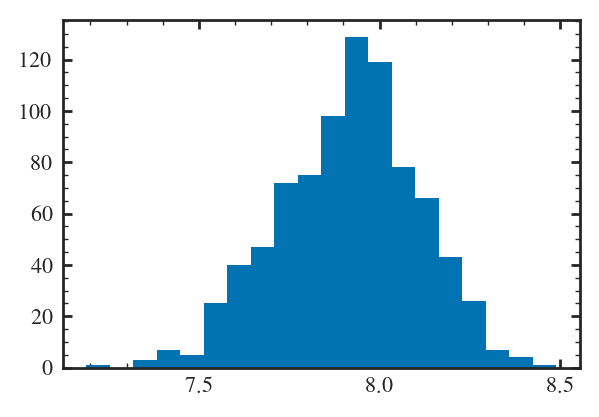

In [247]:
plt.hist(eps_o, bins=20)

In [250]:
good_cat["eps_o"] = eps_o

In [254]:
good_cat.sort_values("eps_o")[["targetid", "ra", "dec", "eps_o"]]

,targetid,ra,dec,eps_o
60225,39627892803503091,324.245069,4.234450,7.189153
376015,2706798091960320,37.598158,26.334539,7.333516
72682,39628365367347021,11.924299,24.790237,7.350098
335497,39627926869643247,201.280378,5.756351,7.373184
642098,39632995849603106,194.272628,35.788367,7.389116
...,...,...,...,...
613808,39632981865795526,254.255439,35.017230,NaN
617007,39633123314503312,250.647992,42.397133,NaN
627620,39628329560574098,202.906310,22.974180,NaN
649943,39633328810232799,182.117537,55.423955,NaN


In [ ]:
good_cat["z

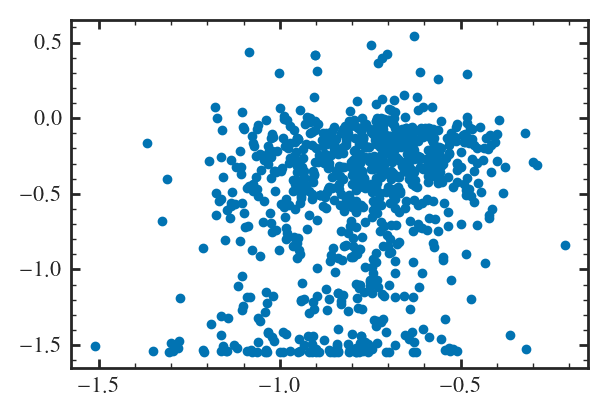

In [265]:
plt.scatter(good_cat.eps_o - 8.7, np.log10(good_cat.z_cg / 0.014))

(6.0, 9.0)

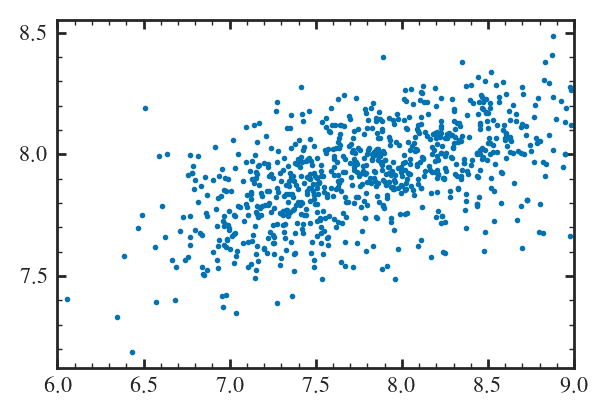

In [268]:
plt.scatter(good_cat.logm_cigale, good_cat.eps_o, s=1)
plt.xlim(6, 9)

In [270]:
from astropy.cosmology import Planck18

In [272]:
cosmo = Planck18

In [274]:
cosmo

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

In [282]:
from astropy import units as u

In [312]:
flux_scale = np.array(good_cat["flux_scale"])

In [378]:
F_Ha = flux_scale * np.array(intens["H1r_6563A"]) * 1e-17  * u.erg / u.s / u.cm**2 # units wrong in documentation?

In [379]:
F_Ha

<Quantity [7.89573412e-14, 2.45444983e-13, 2.27738777e-14, 1.19320869e-13,
           1.34174264e-13, 8.85906681e-14, 6.25957198e-14, 4.91655160e-14,
           5.45968697e-14, 1.62798503e-14, 1.78278610e-14, 3.07143581e-14,
           4.63314927e-14, 2.09456765e-14, 8.42901399e-14, 3.16718719e-14,
           1.11617762e-13, 2.47596701e-14, 3.26443586e-14, 4.19680845e-14,
           4.19292231e-14, 4.19429610e-14, 1.04751974e-14, 2.97957144e-14,
           1.96655225e-14, 3.71913175e-14, 1.89310000e-14, 3.13238254e-14,
           5.95338349e-14, 1.30416730e-14, 1.46810354e-14, 1.98243477e-14,
           3.05709691e-14, 4.57469317e-14, 3.24131751e-14, 1.55872784e-14,
           2.55926117e-14, 2.16454702e-14, 3.01969510e-14, 5.73165012e-14,
           1.01161215e-13, 3.27805900e-14, 1.94879000e-14, 2.11601454e-14,
           2.96963154e-14, 2.34178702e-14, 6.50636595e-14, 1.05850785e-13,
           1.87122786e-14, 1.74355208e-13, 3.53806137e-14, 2.19076022e-14,
           2.50336492e-14

In [380]:
dL**2 

<Quantity [1.84254062e+04, 2.37838349e+04, 2.14921593e+04, 1.68953766e+04,
           1.01211074e+04, 1.81807591e+05, 8.85394376e+04, 7.86309713e+05,
           1.32514913e+04, 1.96242699e+04, 7.53367886e+05, 1.94498046e+04,
           5.65046939e+04, 6.38865127e+05, 1.64014241e+05, 5.84505893e+04,
           2.26235953e+04, 3.13906282e+05, 1.22214788e+05, 9.47354285e+04,
           5.07752771e+04, 2.15344575e+04, 2.30566268e+04, 5.89487968e+04,
           6.18454968e+05, 1.05632714e+05, 9.52457752e+04, 2.78135260e+05,
           1.52451328e+03, 3.27181751e+04, 2.73979856e+04, 1.35901520e+05,
           1.37725175e+04, 5.98365074e+05, 2.40199645e+04, 5.97124972e+05,
           5.86654060e+04, 1.17525125e+05, 1.73994943e+04, 4.60097089e+04,
           2.95184513e+04, 9.75222074e+04, 1.64483210e+05, 7.53751350e+04,
           3.15210134e+04, 3.13115571e+04, 1.08016554e+04, 2.70629153e+03,
           1.86367905e+05, 8.82089858e+03, 4.58336664e+04, 2.97898798e+05,
           7.34830150e+04

In [381]:
dL = cosmo.luminosity_distance(good_cat["z"])
LHa = 4*np.pi * dL**2 * F_Ha
sfr = 7.9e-42 * LHa * u.M_sun /u.yr / u.erg * u.s * 0.63 

In [382]:
sfr = sfr.to("M_sun/yr")

(-2.0, 2.0)

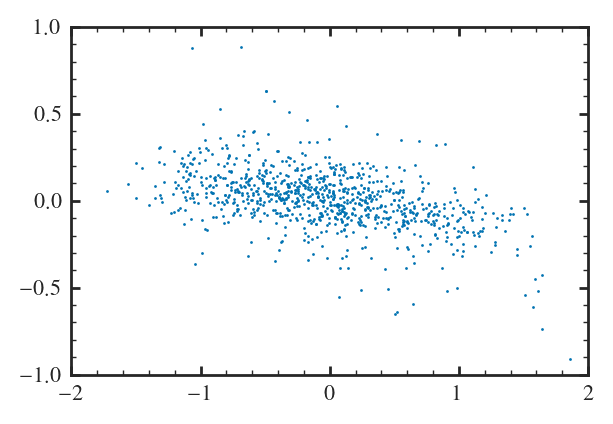

In [383]:
plt.scatter(np.log10(good_cat.sfr_cg), np.log10(sfr.value / good_cat.sfr_cg), s=1, lw=0)
# plt.xlim(6, 10)
# plt.ylim(2.5, 5.5)
plt.ylim(-1, 1)
plt.xlim(-2, 2)